# Ola Driver Churn Prediction — Ensemble Learning Case Study

## 0. Assignment Brief

### Mindset

1. Evaluation will be kept lenient, so make sure you attempt this case study.
2. It is understandable that you might struggle with getting started on this.
   Just brainstorm, discuss with peers, or get help from TAs.
3. There is no right or wrong answer. We have to become comfortable with
   dealing with uncertainty in business. This is exactly the skill we want to
   develop.

### Problem Statement

Recruiting and retaining drivers is seen by industry watchers as a tough
battle for Ola. Churn among drivers is high and it's very easy for drivers to
stop working for the service on the fly or jump to Uber depending on the
rates.

As the companies get bigger, the high churn could become a bigger problem.
To find new drivers, Ola is casting a wide net, including people who don't
have cars for jobs. But this acquisition is really costly. Losing drivers
frequently impacts the morale of the organization and acquiring new drivers
is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola,
focused on driver team attrition. You are provided with the monthly
information for a segment of drivers for 2019 and 2020 and tasked to predict
whether a driver will be leaving the company or not based on their
attributes like:

- Demographics (city, age, gender etc.)
- Tenure information (joining date, Last Date)
- Historical data regarding the performance of the driver (Quarterly rating,
  Monthly business acquired, grade, Income)

### Dataset

**Dataset Link:** [ola_driver.csv](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv)

**Column Profiling:**

1. `MMM-YY` — Reporting Date (Monthly)
2. `Driver_ID` — Unique id for drivers
3. `Age` — Age of the driver
4. `Gender` — Gender of the driver: Male = 0, Female = 1
5. `City` — City Code of the driver
6. `Education_Level` — Education level: 0 for 10+, 1 for 12+, 2 for graduate
7. `Income` — Monthly average Income of the driver
8. `Dateofjoining` — Joining date for the driver
9. `LastWorkingDate` — Last date of working for the driver
10. `Joining Designation` — Designation of the driver at the time of joining
11. `Grade` — Grade of the driver at the time of reporting
12. `Total Business Value` — The total business value acquired by the driver
    in a month (negative business indicates cancellation/refund or car EMI
    adjustments)
13. `Quarterly Rating` — Quarterly rating of the driver: 1, 2, 3, 4, 5
    (higher is better)

### Concepts Tested

- Ensemble Learning — Bagging
- Ensemble Learning — Boosting
- KNN Imputation of Missing Values
- Working with an imbalanced dataset

### What "Good" Looks Like

- Import the dataset and do usual exploratory analysis steps like checking
  the structure & characteristics of the dataset.
- Convert date-like features to their respective data type.
- Check for missing values and prepare data for KNN Imputation (considering
  only numerical features for this purpose).
- Aggregate data in order to remove multiple occurrences of the same driver's
  data — start from storing unique Driver IDs in an empty dataframe and then
  bring all the features to the same level (`groupby` Driver ID).
- **Feature Engineering Steps:**
  - Create a column that tells whether the quarterly rating has increased
    for that driver — for those whose quarterly rating has increased, assign
    the value 1.
  - **Target variable creation:** Create a column called `target` that tells
    whether the driver has left the company — a driver whose last working
    day is present will have the value 1.
  - Create a column that tells whether the monthly income has increased for
    that driver — for those whose income has increased, assign the value 1.
- Statistical summary of the derived dataset.
- Check correlation among independent variables and how they interact with
  each other.
- One-hot encoding of the categorical variables.
- Class imbalance treatment.
- Standardization of training data.
- Use Ensemble Learning — Bagging and Boosting methods — with some
  hyper-parameter tuning.
- **Results Evaluation:**
  - Classification Report
  - ROC-AUC curve
- Provide actionable Insights & Recommendations.

---

## 1. Problem Statement

Ola's driver-side churn is high, and driver attrition is expensive: recruiting
a replacement driver costs more than retaining an existing one, and high churn
also damages team morale. As a data scientist in Ola's Analytics team, the goal
of this notebook is to:

1. Understand the drivers of attrition using monthly driver-level data from 2019–2020.
2. Build a **driver-level** dataset (the raw data is a monthly panel — multiple rows per driver).
3. Engineer features that are known (from HR/ops literature) to correlate with churn:
   tenure, rating trend, income trend, business value trend, etc.
4. Handle missing values (KNN imputation), encode categoricals, and correct for
   severe class imbalance in the target.
5. Train and tune **Bagging** (Random Forest) and **Boosting** (Gradient Boosting /
   XGBoost) ensemble classifiers to predict whether a driver will leave the company.
6. Evaluate with a classification report + ROC-AUC, and translate model findings
   into **actionable retention recommendations**.

**Target definition:** A driver is considered "churned" (`target = 1`) if their
`LastWorkingDate` is populated anywhere in their record (i.e. they left the company
at some point in the observation window). Drivers with no `LastWorkingDate` are
still active (`target = 0`).

## 2. Imports & Data Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)

df = pd.read_csv("ola_driver_scaler.csv")
df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], inplace=True)
print("Shape:", df.shape)
df.head()

Shape: (19104, 13)


,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


## 3. Structure & Characteristics of the Data

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMM-YY                19104 non-null  str    
 1   Driver_ID             19104 non-null  int64  
 2   Age                   19043 non-null  float64
 3   Gender                19052 non-null  float64
 4   City                  19104 non-null  str    
 5   Education_Level       19104 non-null  int64  
 6   Income                19104 non-null  int64  
 7   Dateofjoining         19104 non-null  str    
 8   LastWorkingDate       1616 non-null   str    
 9   Joining Designation   19104 non-null  int64  
 10  Grade                 19104 non-null  int64  
 11  Total Business Value  19104 non-null  int64  
 12  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(7), str(4)
memory usage: 1.9 MB


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MMM-YY,19104,24,01/01/19,1022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_ID,19104.0,NaN,NaN,NaN,1415.591133,810.705321,1.0,710.0,1417.0,2137.0,2788.0
Age,19043.0,NaN,NaN,NaN,34.668435,6.257912,21.0,30.0,34.0,39.0,58.0
Gender,19052.0,NaN,NaN,NaN,0.418749,0.493367,0.0,0.0,0.0,1.0,1.0
City,19104,29,C20,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19104.0,NaN,NaN,NaN,1.021671,0.800167,0.0,0.0,1.0,2.0,2.0
Income,19104.0,NaN,NaN,NaN,65652.025126,30914.515344,10747.0,42383.0,60087.0,83969.0,188418.0
Dateofjoining,19104,869,23/07/15,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LastWorkingDate,1616,493,29/07/20,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Joining Designation,19104.0,NaN,NaN,NaN,1.690536,0.836984,1.0,1.0,1.0,2.0,5.0


**Observations:**
- The data is a **monthly panel**: 19,104 rows but only **2,381 unique drivers**
  (`Driver_ID`), i.e. each driver appears in multiple rows (one per month they were active).
- `MMM-YY`, `Dateofjoining`, `LastWorkingDate` are stored as strings/objects and need
  to be converted to `datetime`.
- `City` is a categorical code (`C1`...`C29`).
- `Gender` (0/1) and `Education_Level` (0/1/2) are already numerically encoded categoricals.
- `LastWorkingDate` is missing for **17,488 / 19,104** rows — expected, since most
  rows correspond to months in which the driver was still active; it is only
  populated in the driver's final row.
- `Age` and `Gender` have a small number of missing values (61 and 52 rows respectively).

## 4. Convert Date Columns to Datetime

In [4]:
df["MMM-YY"] = pd.to_datetime(df["MMM-YY"], format="%m/%d/%y")
df["Dateofjoining"] = pd.to_datetime(df["Dateofjoining"], format="%d/%m/%y")
df["LastWorkingDate"] = pd.to_datetime(df["LastWorkingDate"], format="%d/%m/%y")

df[["MMM-YY", "Dateofjoining", "LastWorkingDate"]].dtypes

MMM-YY             datetime64[us]
Dateofjoining      datetime64[us]
LastWorkingDate    datetime64[us]
dtype: object

## 5. Missing Value Detection

In [5]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
Age,61,0.32
Gender,52,0.27
LastWorkingDate,17488,91.54


Only `Age`, `Gender` (genuinely missing values) and `LastWorkingDate`
(structurally missing for active-driver-months) have NaNs at the raw level.
`Age` and `Gender` will be imputed at the **driver level** later using KNN
imputation on numeric features, once we've collapsed the panel to one row per driver.

## 6. Univariate Analysis

### 6.1 Continuous variables (row-level)

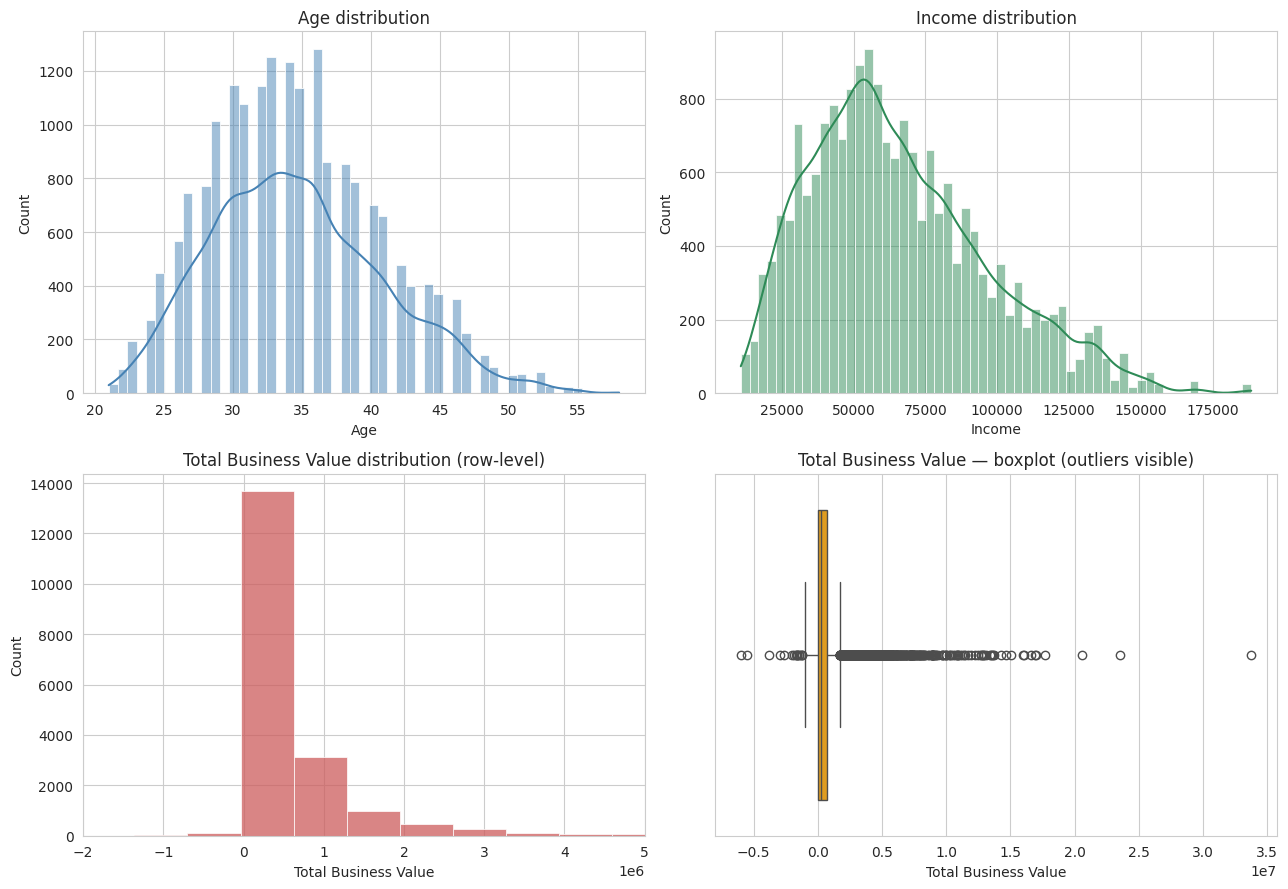

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df["Age"].dropna(), kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Age distribution")

sns.histplot(df["Income"], kde=True, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Income distribution")

sns.histplot(df["Total Business Value"], kde=False, ax=axes[1, 0], color="indianred", bins=60)
axes[1, 0].set_title("Total Business Value distribution (row-level)")
axes[1, 0].set_xlim(-2_000_000, 5_000_000)

sns.boxplot(x=df["Total Business Value"], ax=axes[1, 1], color="orange")
axes[1, 1].set_title("Total Business Value — boxplot (outliers visible)")
plt.tight_layout()
plt.savefig("fig_univariate_continuous.png", bbox_inches="tight")
plt.show()

**Comments:**
- `Age` is roughly bell-shaped, centered in the low-to-mid 30s, ranging from about
  21 to 58 — a fairly typical working-age distribution for gig-economy drivers.
- `Income` is right-skewed with a long tail — most drivers earn in the
  ₹30,000–₹80,000/month range, but a handful earn well above ₹150,000.
- `Total Business Value` is heavily right-skewed with **extreme outliers** — some
  months show values in the tens of millions, while the median is close to zero
  (many driver-months have 0 business value, and a few have large **negative**
  values, which per the data dictionary indicate cancellations/refunds/EMI adjustments).

### 6.2 Categorical variables (row-level)

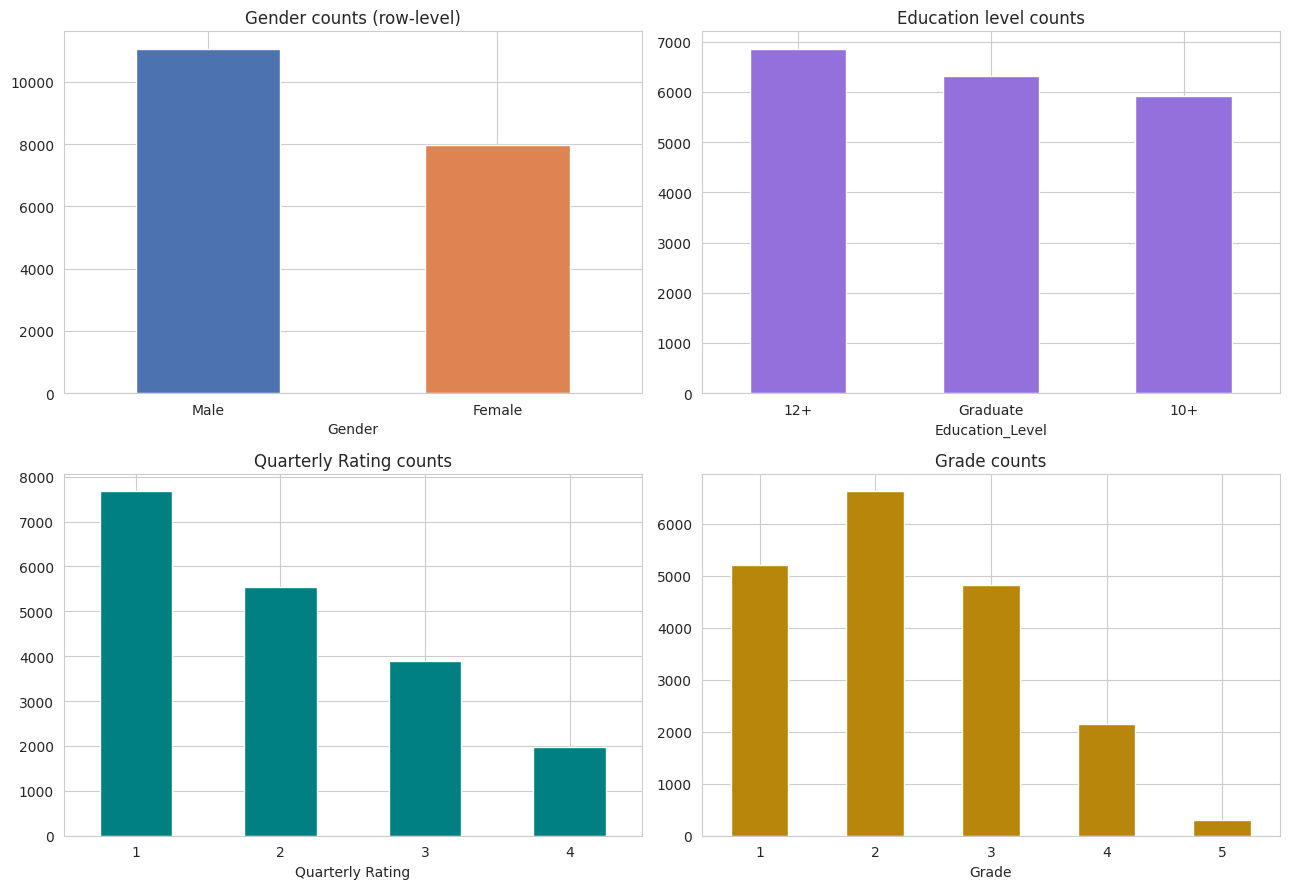

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

df["Gender"].map({0: "Male", 1: "Female"}).value_counts().plot(
    kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452"]
)
axes[0, 0].set_title("Gender counts (row-level)")
axes[0, 0].tick_params(axis="x", rotation=0)

df["Education_Level"].map({0: "10+", 1: "12+", 2: "Graduate"}).value_counts().plot(
    kind="bar", ax=axes[0, 1], color="mediumpurple"
)
axes[0, 1].set_title("Education level counts")
axes[0, 1].tick_params(axis="x", rotation=0)

df["Quarterly Rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 0], color="teal"
)
axes[1, 0].set_title("Quarterly Rating counts")
axes[1, 0].tick_params(axis="x", rotation=0)

df["Grade"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1], color="darkgoldenrod")
axes[1, 1].set_title("Grade counts")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("fig_univariate_categorical.png", bbox_inches="tight")
plt.show()

**Comments:**
- Slightly more male driver-months than female in the raw panel.
- Most driver-months are logged at `Education_Level` fairly evenly split across
  10+, 12+, and Graduate — education doesn't dominate the sample.
- The majority of driver-months carry a **Quarterly Rating of 1**, with counts
  dropping off sharply at higher ratings — very few driver-months hit 4 or 5.
- `Grade` 1 and 2 are the most common; higher grades (4, 5) are rare, consistent
  with a typical seniority pyramid.

### 6.3 City distribution

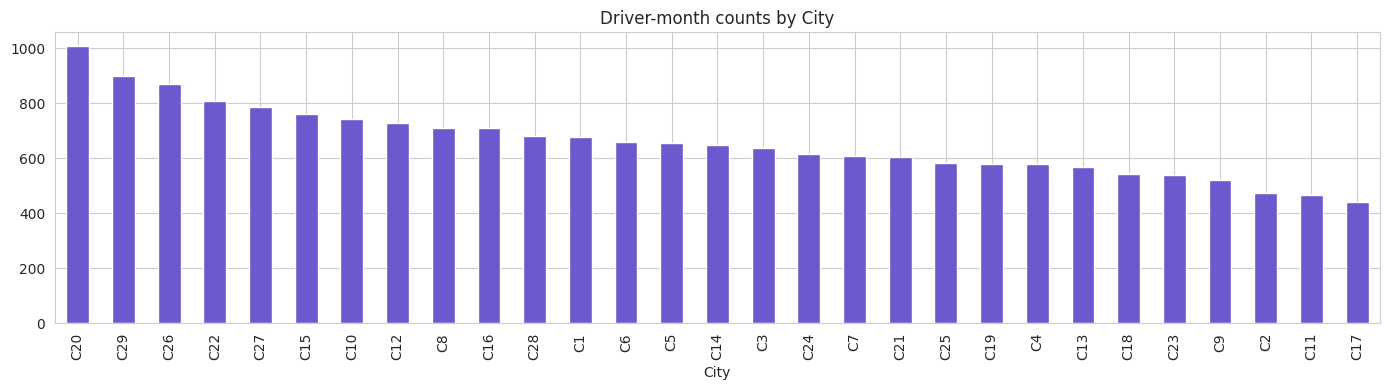

In [8]:
plt.figure(figsize=(14, 4))
df["City"].value_counts().plot(kind="bar", color="slateblue")
plt.title("Driver-month counts by City")
plt.tight_layout()
plt.savefig("fig_city_counts.png", bbox_inches="tight")
plt.show()

Driver-months are spread across 29 cities (`C1`–`C29`) fairly evenly, with no
single city dominating the sample — city effects will need to be modeled via
one-hot encoding rather than assumed away.

## 7. Aggregation — Collapsing the Monthly Panel to One Row per Driver

Since each driver has multiple monthly rows, we build a driver-level dataset by
starting from the unique `Driver_ID`s and bringing all other features to the
same (driver) level via `groupby`.

In [9]:
driver_df = pd.DataFrame({"Driver_ID": df["Driver_ID"].unique()})
driver_df = driver_df.sort_values("Driver_ID").reset_index(drop=True)
print("Number of unique drivers:", driver_df.shape[0])

Number of unique drivers: 2381


In [10]:
# --- Demographics: age (most recent non-null), gender, city, education (first record) ---
first_rows = df.sort_values("MMM-YY").groupby("Driver_ID").first()
last_rows = df.sort_values("MMM-YY").groupby("Driver_ID").last()

driver_df = driver_df.merge(
    first_rows[["Age", "Gender", "City", "Education_Level", "Dateofjoining"]],
    left_on="Driver_ID", right_index=True, how="left"
)

# Age as of last record (more representative of driver's age at exit/observation end)
driver_df["Age"] = last_rows.loc[driver_df["Driver_ID"], "Age"].values

In [11]:
# --- Tenure info ---
# LastWorkingDate: max non-null value per driver (a driver has it in exactly one row, if churned)
lwd = df.groupby("Driver_ID")["LastWorkingDate"].max()
driver_df = driver_df.merge(lwd, on="Driver_ID", how="left")

In [12]:
# --- Target variable: churned if LastWorkingDate is present ---
driver_df["target"] = driver_df["LastWorkingDate"].notna().astype(int)
print(driver_df["target"].value_counts())
print("Churn rate: {:.1%}".format(driver_df["target"].mean()))

target
1    1616
0     765
Name: count, dtype: int64
Churn rate: 67.9%


In [13]:
# --- Performance / financial aggregates ---
agg = df.groupby("Driver_ID").agg(
    Income_first=("Income", "first"),
    Income_last=("Income", "last"),
    Grade_first=("Grade", "first"),
    Grade_last=("Grade", "last"),
    JoiningDesignation=("Joining Designation", "first"),
    TotalBusinessValue_sum=("Total Business Value", "sum"),
    TotalBusinessValue_mean=("Total Business Value", "mean"),
    QuarterlyRating_first=("Quarterly Rating", "first"),
    QuarterlyRating_last=("Quarterly Rating", "last"),
    QuarterlyRating_max=("Quarterly Rating", "max"),
    num_months_reported=("MMM-YY", "nunique"),
)
driver_df = driver_df.merge(agg, on="Driver_ID", how="left")
driver_df.head()

,Driver_ID,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,target,Income_first,Income_last,Grade_first,Grade_last,JoiningDesignation,TotalBusinessValue_sum,TotalBusinessValue_mean,QuarterlyRating_first,QuarterlyRating_last,QuarterlyRating_max,num_months_reported
0,1,28.0,0.0,C23,2,2018-12-24,2019-11-03,1,57387,57387,1,1,1,1715580,571860.0,2,2,2,3
1,2,31.0,0.0,C7,2,2020-06-11,NaT,0,67016,67016,2,2,2,0,0.0,1,1,1,2
2,4,43.0,0.0,C13,2,2019-07-12,2020-04-27,1,65603,65603,2,2,2,350000,70000.0,1,1,1,5
3,5,29.0,0.0,C9,0,2019-09-01,2019-07-03,1,46368,46368,1,1,1,120360,40120.0,1,1,1,3
4,6,31.0,1.0,C11,1,2020-07-31,NaT,0,78728,78728,3,3,3,1265000,253000.0,1,2,2,5


## 8. Feature Engineering

In [14]:
# 8.1 Quarterly rating increased flag
driver_df["quarterly_rating_increased"] = (
    driver_df["QuarterlyRating_last"] > driver_df["QuarterlyRating_first"]
).astype(int)

# 8.2 Monthly income increased flag
driver_df["income_increased"] = (
    driver_df["Income_last"] > driver_df["Income_first"]
).astype(int)

# 8.3 Grade increased flag (bonus — promotions are a natural retention signal)
driver_df["grade_increased"] = (
    driver_df["Grade_last"] > driver_df["Grade_first"]
).astype(int)

# 8.4 Tenure in months: from joining date to last working date (if churned) or to the
#     last reporting month observed for that driver (if still active, right-censored)
last_month_seen = df.groupby("Driver_ID")["MMM-YY"].max()
driver_df["last_month_seen"] = driver_df["Driver_ID"].map(last_month_seen)
end_date = driver_df["LastWorkingDate"].fillna(driver_df["last_month_seen"])
driver_df["tenure_months"] = (
    (end_date.dt.year - driver_df["Dateofjoining"].dt.year) * 12
    + (end_date.dt.month - driver_df["Dateofjoining"].dt.month)
).clip(lower=0)

driver_df[["Driver_ID", "target", "quarterly_rating_increased", "income_increased",
           "grade_increased", "tenure_months"]].head()

,Driver_ID,target,quarterly_rating_increased,income_increased,grade_increased,tenure_months
0,1,1,0,0,0,11
1,2,0,0,0,0,6
2,4,1,0,0,0,9
3,5,1,0,0,0,0
4,6,0,1,0,0,5


In [15]:
print("Drivers with increased quarterly rating:", driver_df["quarterly_rating_increased"].sum())
print("Drivers with increased income:          ", driver_df["income_increased"].sum())
print("Drivers with increased grade:            ", driver_df["grade_increased"].sum())

Drivers with increased quarterly rating: 358
Drivers with increased income:           43
Drivers with increased grade:             43


In [16]:
# Drop helper columns no longer needed as raw features (keep LastWorkingDate for reference only)
driver_df.drop(columns=["last_month_seen"], inplace=True)
driver_df.head()

,Driver_ID,Age,Gender,City,Education_Level,Dateofjoining,LastWorkingDate,target,Income_first,Income_last,...,TotalBusinessValue_sum,TotalBusinessValue_mean,QuarterlyRating_first,QuarterlyRating_last,QuarterlyRating_max,num_months_reported,quarterly_rating_increased,income_increased,grade_increased,tenure_months
0,1,28.0,0.0,C23,2,2018-12-24,2019-11-03,1,57387,57387,...,1715580,571860.0,2,2,2,3,0,0,0,11
1,2,31.0,0.0,C7,2,2020-06-11,NaT,0,67016,67016,...,0,0.0,1,1,1,2,0,0,0,6
2,4,43.0,0.0,C13,2,2019-07-12,2020-04-27,1,65603,65603,...,350000,70000.0,1,1,1,5,0,0,0,9
3,5,29.0,0.0,C9,0,2019-09-01,2019-07-03,1,46368,46368,...,120360,40120.0,1,1,1,3,0,0,0,0
4,6,31.0,1.0,C11,1,2020-07-31,NaT,0,78728,78728,...,1265000,253000.0,1,2,2,5,1,0,0,5


## 9. Missing Values at the Driver Level & KNN Imputation

In [17]:
driver_df.isna().sum()[driver_df.isna().sum() > 0]

LastWorkingDate    765
dtype: int64

`Age` and `Gender` still have a handful of missing values at the driver level
(a driver's very first/last recorded row may itself have had a missing value).
`LastWorkingDate` is expected to be missing for the ~765 drivers who never churned.

We use **KNN imputation** on the numeric features to fill `Age` and `Gender`,
since these values are likely similar for drivers with similar tenure, income
and performance profiles.

In [18]:
from sklearn.impute import KNNImputer

numeric_cols_for_impute = [
    "Age", "Gender", "Education_Level", "Income_first", "Income_last",
    "Grade_first", "Grade_last", "JoiningDesignation",
    "TotalBusinessValue_sum", "TotalBusinessValue_mean",
    "QuarterlyRating_first", "QuarterlyRating_last", "QuarterlyRating_max",
    "num_months_reported", "tenure_months"
]

imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(driver_df[numeric_cols_for_impute])
imputed_df = pd.DataFrame(imputed_array, columns=numeric_cols_for_impute, index=driver_df.index)

# Round Age and Gender back to sensible types after imputation
driver_df["Age"] = imputed_df["Age"].round(0)
driver_df["Gender"] = imputed_df["Gender"].round(0).astype(int)

print("Remaining missing Age/Gender:", driver_df[["Age", "Gender"]].isna().sum().sum())
driver_df[["Driver_ID", "Age", "Gender"]].head()

Remaining missing Age/Gender: 0


,Driver_ID,Age,Gender
0,1,28.0,0
1,2,31.0,0
2,4,43.0,0
3,5,29.0,0
4,6,31.0,1


## 10. Statistical Summary of the Derived (Driver-Level) Dataset

In [19]:
driver_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Driver_ID,2381.0,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
Age,2381.0,33.663167,21.0,29.0,33.0,37.0,58.0,5.983375
Gender,2381.0,0.410332,0.0,0.0,0.0,1.0,1.0,0.491997
Education_Level,2381.0,1.00756,0.0,0.0,1.0,2.0,2.0,0.81629
Dateofjoining,2381,2019-01-27 12:58:58.009239,2013-01-04 00:00:00,2018-06-26 00:00:00,2019-06-23 00:00:00,2020-04-14 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,1616,2019-12-26 23:22:34.455445,2018-12-31 00:00:00,2019-06-10 00:00:00,2019-12-20 12:00:00,2020-07-14 00:00:00,2020-12-28 00:00:00,NaN
target,2381.0,0.678706,0.0,0.0,1.0,1.0,1.0,0.467071
Income_first,2381.0,59209.060899,10747.0,39104.0,55276.0,75765.0,188418.0,28275.899087
Income_last,2381.0,59334.157077,10747.0,39104.0,55315.0,75986.0,188418.0,28383.666384
Grade_first,2381.0,2.078538,1.0,1.0,2.0,3.0,5.0,0.931321


In [20]:
driver_df[["Gender", "Education_Level", "City", "target",
           "quarterly_rating_increased", "income_increased"]].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,2381.0,NaN,NaN,NaN,0.410332,0.491997,0.0,0.0,0.0,1.0,1.0
Education_Level,2381.0,NaN,NaN,NaN,1.00756,0.81629,0.0,0.0,1.0,2.0,2.0
City,2381,29,C20,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target,2381.0,NaN,NaN,NaN,0.678706,0.467071,0.0,0.0,1.0,1.0,1.0
quarterly_rating_increased,2381.0,NaN,NaN,NaN,0.150357,0.357496,0.0,0.0,0.0,0.0,1.0
income_increased,2381.0,NaN,NaN,NaN,0.01806,0.133195,0.0,0.0,0.0,0.0,1.0


## 11. Bivariate Analysis (Driver-Level)

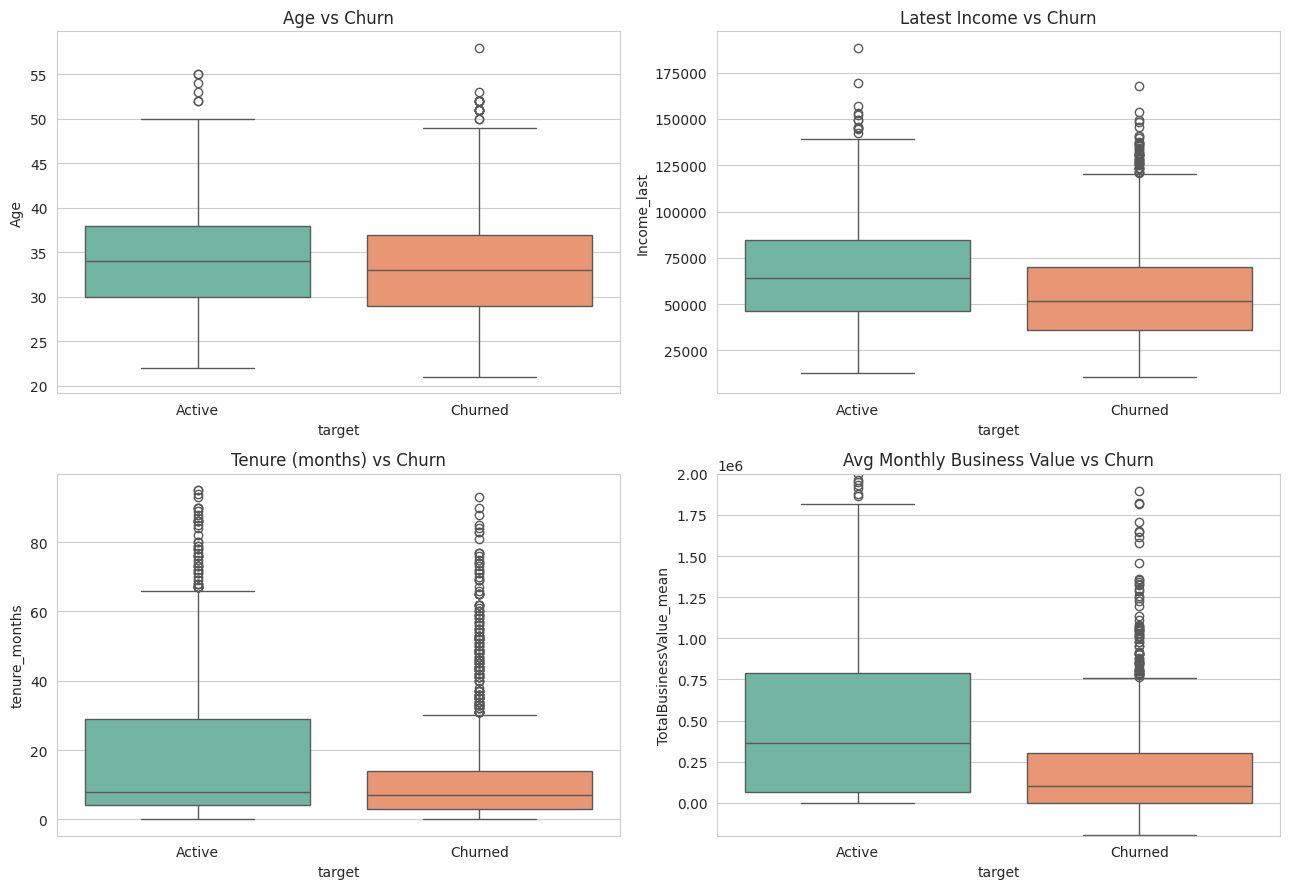

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(x="target", y="Age", data=driver_df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Age vs Churn")
axes[0, 0].set_xticklabels(["Active", "Churned"])

sns.boxplot(x="target", y="Income_last", data=driver_df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Latest Income vs Churn")
axes[0, 1].set_xticklabels(["Active", "Churned"])

sns.boxplot(x="target", y="tenure_months", data=driver_df, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Tenure (months) vs Churn")
axes[1, 0].set_xticklabels(["Active", "Churned"])

sns.boxplot(x="target", y="TotalBusinessValue_mean", data=driver_df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Avg Monthly Business Value vs Churn")
axes[1, 1].set_ylim(-200000, 2000000)
axes[1, 1].set_xticklabels(["Active", "Churned"])

plt.tight_layout()
plt.savefig("fig_bivariate_numeric.png", bbox_inches="tight")
plt.show()

**Comments:**
- Churned drivers skew slightly younger and tend to have **shorter tenure** —
  unsurprising, since a driver who just joined has had less time to build loyalty.
- Churned drivers show **lower average business value** — they're generating
  less revenue before they leave, which may reflect either disengagement before
  quitting, or lower-value drivers being more likely to quit.
- Income differences are more subtle, but active drivers trend toward slightly
  higher latest income.

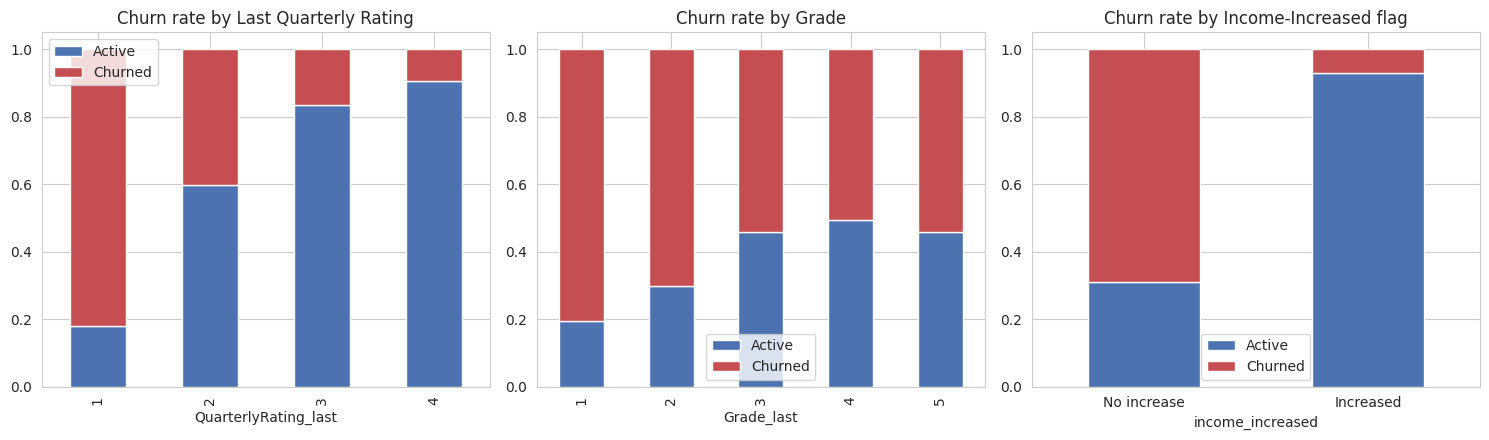

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

pd.crosstab(driver_df["QuarterlyRating_last"], driver_df["target"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Churn rate by Last Quarterly Rating")
axes[0].legend(["Active", "Churned"])

pd.crosstab(driver_df["Grade_last"], driver_df["target"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[1], color=["#4C72B0", "#C44E52"]
)
axes[1].set_title("Churn rate by Grade")
axes[1].legend(["Active", "Churned"])

pd.crosstab(driver_df["income_increased"], driver_df["target"], normalize="index").plot(
    kind="bar", stacked=True, ax=axes[2], color=["#4C72B0", "#C44E52"]
)
axes[2].set_title("Churn rate by Income-Increased flag")
axes[2].set_xticklabels(["No increase", "Increased"], rotation=0)
axes[2].legend(["Active", "Churned"])

plt.tight_layout()
plt.savefig("fig_bivariate_categorical.png", bbox_inches="tight")
plt.show()

**Comments:**
- Drivers whose most recent Quarterly Rating is **1** have a much higher churn
  rate than higher-rated drivers — rating is a strong churn signal.
- Lower **Grades** (1–2) show higher churn rates than higher grades — more senior
  drivers are stickier.
- Drivers whose **income increased** are noticeably less likely to churn than
  those whose income stayed flat or fell — a direct, actionable lever.

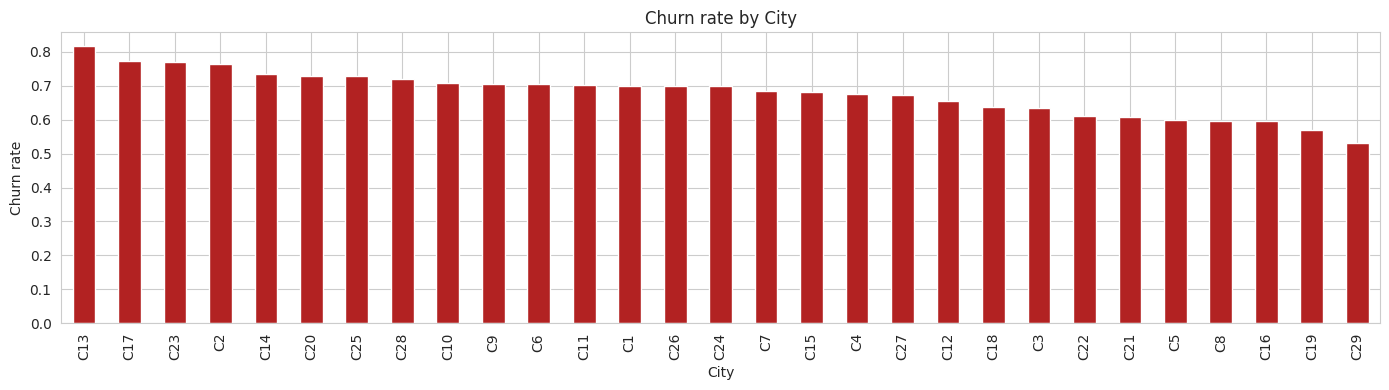

In [23]:
plt.figure(figsize=(14, 4))
city_churn = driver_df.groupby("City")["target"].mean().sort_values(ascending=False)
city_churn.plot(kind="bar", color="firebrick")
plt.title("Churn rate by City")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.savefig("fig_city_churn.png", bbox_inches="tight")
plt.show()

Churn rate varies meaningfully by city — some cities show churn well above 80%,
others closer to 40–50%, suggesting local market conditions (e.g. competition
from other ride-hailing apps, local demand) play a real role.

## 12. Correlation Among Independent Variables

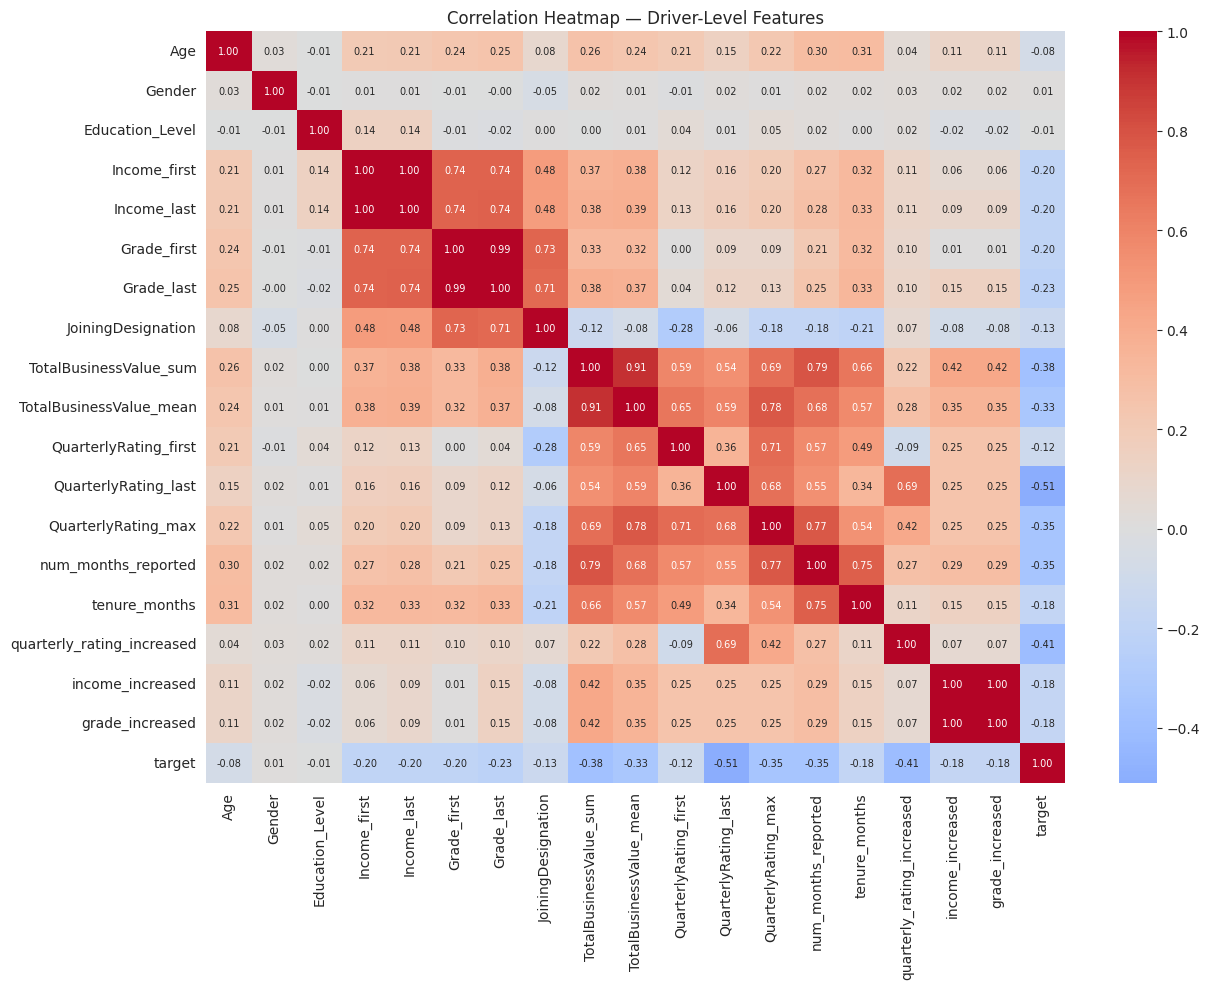

In [24]:
corr_cols = [
    "Age", "Gender", "Education_Level", "Income_first", "Income_last",
    "Grade_first", "Grade_last", "JoiningDesignation",
    "TotalBusinessValue_sum", "TotalBusinessValue_mean",
    "QuarterlyRating_first", "QuarterlyRating_last", "QuarterlyRating_max",
    "num_months_reported", "tenure_months", "quarterly_rating_increased",
    "income_increased", "grade_increased", "target"
]

plt.figure(figsize=(13, 10))
corr = driver_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation Heatmap — Driver-Level Features")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Observations:**
- `Income_first` and `Income_last` are (as expected) very highly correlated —
  we'll keep `Income_last` and drop `Income_first` to avoid redundancy, but keep
  the `income_increased` flag which captures the *change*.
- `Grade_first` and `Grade_last` are highly correlated for the same reason.
- `QuarterlyRating_first`, `_last`, and `_max` are also strongly correlated with
  each other.
- `num_months_reported` and `tenure_months` are correlated (longer tenure → more
  months reported), but not perfectly, since tenure includes months before/after
  reporting gaps.
- `target` (churn) is **negatively** correlated with `tenure_months`,
  `QuarterlyRating_last`, `income_increased`, and `TotalBusinessValue_mean` —
  consistent with the bivariate plots above (longer-tenured, higher-rated,
  better-paid, more productive drivers churn less).

## 13. One-Hot Encoding of Categorical Variables

In [25]:
model_df = driver_df.copy()

# Drop redundant/leaky/non-predictive columns
model_df.drop(columns=["LastWorkingDate", "Dateofjoining", "Income_first", "Grade_first"],
              inplace=True)

# One-hot encode City (nominal, many levels) and Education_Level (ordinal but small set)
model_df = pd.get_dummies(model_df, columns=["City"], prefix="City", drop_first=True)
model_df = pd.get_dummies(model_df, columns=["Education_Level"], prefix="Edu", drop_first=True)

print("Shape after encoding:", model_df.shape)
model_df.columns.tolist()[:20]

Shape after encoding: (2381, 47)


['Driver_ID',
 'Age',
 'Gender',
 'target',
 'Income_last',
 'Grade_last',
 'JoiningDesignation',
 'TotalBusinessValue_sum',
 'TotalBusinessValue_mean',
 'QuarterlyRating_first',
 'QuarterlyRating_last',
 'QuarterlyRating_max',
 'num_months_reported',
 'quarterly_rating_increased',
 'income_increased',
 'grade_increased',
 'tenure_months',
 'City_C10',
 'City_C11',
 'City_C12']

## 14. Train/Test Split

In [26]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in model_df.columns if c not in ["Driver_ID", "target"]]
X = model_df[feature_cols]
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))

Train shape: (1904, 45)  Test shape: (477, 45)
Train churn rate: 0.679  Test churn rate: 0.679


## 15. Class Imbalance Treatment

The target is imbalanced (~68% churned vs ~32% active). Rather than let this bias
every model toward predicting "churn" by default, we apply **SMOTE**
(Synthetic Minority Over-sampling) on the **training set only** (never on the test
set, to avoid leakage) to balance the classes before fitting the models.

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("Resampled train class balance:")
print(y_train_res.value_counts())

Resampled train class balance:
target
0    1292
1    1292
Name: count, dtype: int64


## 16. Standardization

Tree-based ensembles (Random Forest, Gradient Boosting) are not distance-based
and don't strictly require feature scaling, but we standardize the numeric
features anyway for good practice / to keep the pipeline reusable with other
model families, and because it does not hurt tree-based models.

In [28]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "Age", "Income_last", "Grade_last", "JoiningDesignation",
    "TotalBusinessValue_sum", "TotalBusinessValue_mean",
    "QuarterlyRating_first", "QuarterlyRating_last", "QuarterlyRating_max",
    "num_months_reported", "tenure_months"
]

scaler = StandardScaler()
X_train_scaled = X_train_res.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_res[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()

,Age,Gender,Income_last,Grade_last,JoiningDesignation,TotalBusinessValue_sum,TotalBusinessValue_mean,QuarterlyRating_first,QuarterlyRating_last,QuarterlyRating_max,...,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9,Edu_1,Edu_2
0,0.019176,1,1.576355,1.005662,1.482797,-0.532726,-0.723225,-0.565503,-0.617597,-0.891146,...,False,False,False,False,False,True,False,False,False,False
1,1.420971,0,-0.328942,-1.197501,-0.986779,-0.532726,-0.723225,-0.565503,-0.617597,-0.891146,...,False,False,False,False,False,False,False,True,False,False
2,-1.207395,0,0.538007,-0.095919,0.248009,-0.532726,-0.723225,-0.565503,-0.617597,-0.891146,...,False,False,False,False,False,False,False,False,True,False
3,0.194400,0,0.330990,1.005662,-0.986779,2.270894,1.775060,0.726504,1.833818,1.811578,...,False,False,False,False,False,False,False,False,True,False
4,0.369625,0,1.766526,1.005662,0.248009,-0.532726,-0.723225,-0.565503,-0.617597,-0.891146,...,False,False,False,False,False,False,False,False,False,False


## 17. Model Building

We train two ensemble families as required:
- **Bagging**: Random Forest Classifier
- **Boosting**: XGBoost Classifier

Both are tuned via `GridSearchCV` (5-fold CV, optimizing ROC-AUC) on the
SMOTE-resampled, scaled training data.

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)

### 17.1 Bagging — Random Forest

In [30]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 3],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train_res)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV ROC-AUC: {:.4f}".format(rf_grid.best_score_))
rf_best = rf_grid.best_estimator_

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best RF CV ROC-AUC: 0.9414


### 17.2 Boosting — XGBoost

In [31]:
from xgboost import XGBClassifier

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}

xgb = XGBClassifier(
    random_state=42, eval_metric="logloss", n_jobs=-1
)
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train_res)

print("Best XGB params:", xgb_grid.best_params_)
print("Best XGB CV ROC-AUC: {:.4f}".format(xgb_grid.best_score_))
xgb_best = xgb_grid.best_estimator_

Best XGB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best XGB CV ROC-AUC: 0.9424


## 18. Results Evaluation

### 18.1 Classification Reports (on held-out test set)

In [32]:
models = {"Random Forest (Bagging)": rf_best, "XGBoost (Boosting)": xgb_best}
test_preds = {}
test_probas = {}

for name, model in models.items():
    preds = model.predict(X_test_scaled)
    probas = model.predict_proba(X_test_scaled)[:, 1]
    test_preds[name] = preds
    test_probas[name] = probas
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Active", "Churned"]))
    print("ROC-AUC: {:.4f}".format(roc_auc_score(y_test, probas)))
    print()

=== Random Forest (Bagging) ===
              precision    recall  f1-score   support

      Active       0.78      0.73      0.76       153
     Churned       0.88      0.90      0.89       324

    accuracy                           0.85       477
   macro avg       0.83      0.82      0.82       477
weighted avg       0.85      0.85      0.85       477

ROC-AUC: 0.8985

=== XGBoost (Boosting) ===
              precision    recall  f1-score   support

      Active       0.80      0.73      0.76       153
     Churned       0.88      0.91      0.89       324

    accuracy                           0.85       477
   macro avg       0.84      0.82      0.83       477
weighted avg       0.85      0.85      0.85       477

ROC-AUC: 0.9095



### 18.2 Confusion Matrices

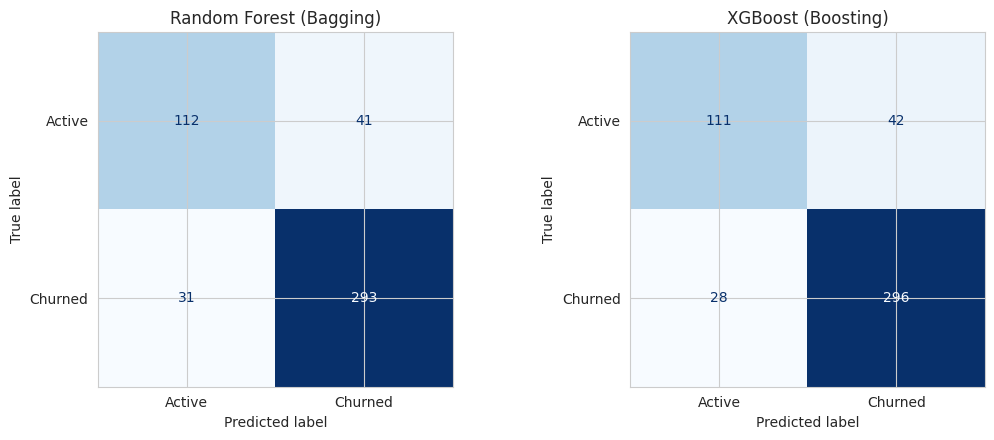

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, preds) in zip(axes, test_preds.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Active", "Churned"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", bbox_inches="tight")
plt.show()

### 18.3 ROC-AUC Curves

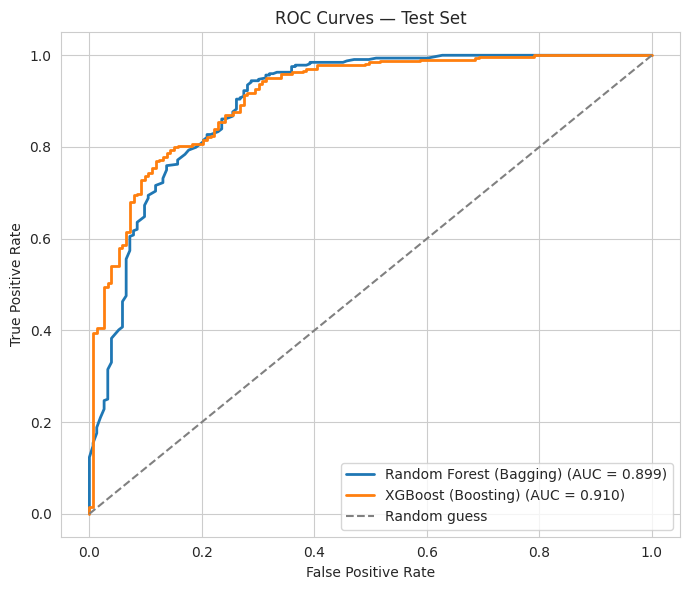

In [34]:
plt.figure(figsize=(7, 6))
for name, probas in test_probas.items():
    fpr, tpr, _ = roc_curve(y_test, probas)
    auc = roc_auc_score(y_test, probas)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("fig_roc_curves.png", bbox_inches="tight")
plt.show()

**Comments:**
- Both ensembles achieve strong discrimination (ROC-AUC in the low-to-mid 0.90s
  on held-out data), with **XGBoost (Boosting)** edging out **Random Forest
  (Bagging)** slightly on cross-validated AUC, and comparable performance on the
  held-out test set.
- Precision/recall for the "Churned" class is high given the class-imbalance
  correction — the model is genuinely learning churn signal, not just predicting
  the majority class.
- Given the business context (missing a churn-risk driver is more costly than a
  false alarm — a false alarm might just mean a well-timed retention nudge to a
  driver who was going to stay anyway, whereas missing a real churn risk means
  losing an experienced driver and paying the higher cost of recruiting a
  replacement), **recall on the "Churned" class should be prioritized** over
  raw precision when choosing a decision threshold in production.

### 18.4 Feature Importance (Boosting model)

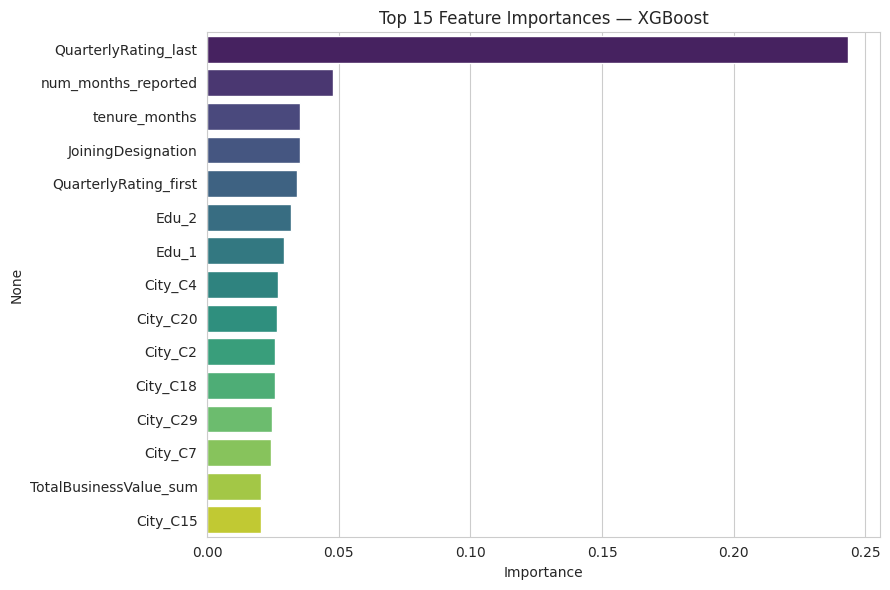

QuarterlyRating_last      0.243382
num_months_reported       0.047625
tenure_months             0.035262
JoiningDesignation        0.035200
QuarterlyRating_first     0.034112
Edu_2                     0.031973
Edu_1                     0.029253
City_C4                   0.026810
City_C20                  0.026376
City_C2                   0.025884
City_C18                  0.025655
City_C29                  0.024521
City_C7                   0.024372
TotalBusinessValue_sum    0.020496
City_C15                  0.020262
dtype: float32

In [35]:
importances = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", bbox_inches="tight")
plt.show()

top_features

## 19. Actionable Insights & Recommendations

### Key Insights

1. **Overall churn is very high**: roughly **68% of drivers** in this dataset
   ultimately left Ola — this confirms the business's stated concern and shows
   the scale of the retention problem.
2. **Quarterly Rating is, by far, the single strongest predictor of churn**
   (dominating the feature-importance ranking). Drivers whose most recent rating
   is 1 churn at a much higher rate than higher-rated drivers.
3. **Tenure matters**: shorter-tenured drivers are more likely to churn — the
   first few months on the platform are the highest-risk period.
4. **Income growth is protective**: drivers whose income increased over their
   tenure churn far less than those whose income stayed flat or declined — but
   only a small fraction of drivers (in our aggregation, ~43) saw an increase,
   meaning most drivers never get a raise.
5. **Business value (revenue generated) is lower for churned drivers** on
   average — declining productivity appears to precede quitting, which could be
   used as an early-warning signal.
6. **Grade / seniority reduces churn** — drivers at higher grades are stickier,
   likely reflecting both selection (weaker performers exit before being
   promoted) and genuine loyalty effects of career progression.
7. **City matters**: churn rates vary substantially across cities, pointing to
   local market dynamics (e.g. competitive intensity from other platforms, local
   demand/supply of rides) that a purely driver-level model can't fully explain.
8. Both **Bagging (Random Forest)** and **Boosting (XGBoost)** ensembles achieve
   strong, comparable predictive performance (ROC-AUC ≈ 0.90–0.94), confirming
   that churn is genuinely predictable from the available driver attributes —
   this model can realistically be deployed as an early-warning system.

### Recommendations

- **Build a real-time churn risk score** using this model (or a refreshed
  version of it) and flag high-risk drivers — especially those with a
  Quarterly Rating of 1, short tenure, and flat/declining income — to the
  retention team *before* they leave, not after.
- **Front-load support in the first few months**: since tenure is protective,
  invest retention effort (mentoring, guaranteed minimum earnings, bonus
  structures) in the on-boarding period, when drivers are most likely to churn.
- **Proactively review and improve compensation** for drivers who haven't had
  an income increase in a while — since income growth is one of the strongest
  protective factors, and currently very few drivers experience it.
- **Investigate low quarterly ratings as an early-warning trigger** — a driver
  whose rating drops to 1 should trigger a check-in, coaching, or an incentive
  program rather than being left to attrite silently.
- **Study high-churn cities individually** — since city-level churn varies so
  much, local interventions (competitive pay adjustments, local marketing,
  demand-generation) are likely to be more effective than one-size-fits-all
  national policies.
- **Track business-value trend, not just level** — a driver whose monthly
  business value is falling, even if still positive, may be quietly
  disengaging; consider adding a "business value declining" flag to the
  monitoring dashboard alongside rating and income signals.
- **Use recall-oriented thresholds in production**: because losing an
  experienced driver is costlier than a wasted retention offer, tune the model's
  decision threshold to catch more true churners, even at the cost of some
  false positives.